Preprocessing + DataLoaders

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Layers equivalents in PyTorch
# (We'll define LSTM, GRU, Dense layers inside a custom nn.Module later)
from torch.nn import LSTM, GRU, Linear, Dropout, BatchNorm1d

# Sklearn preprocessing & metrics
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import recall_score, roc_auc_score, accuracy_score, f1_score
# Data balancing & missing value handling
from imblearn.over_sampling import SMOTE
from sklearn.impute import SimpleImputer


In [ ]:
# Load the dataset
df = pd.read_csv("Datasets/dhi.csv")

# Display the first few rows of the dataset
df

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253675,0.0,1.0,1.0,1.0,45.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,5.0,0.0,1.0,5.0,6.0,7.0
253676,1.0,1.0,1.0,1.0,18.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,4.0,0.0,0.0,1.0,0.0,11.0,2.0,4.0
253677,0.0,0.0,0.0,1.0,28.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,2.0,5.0,2.0
253678,0.0,1.0,0.0,1.0,23.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,7.0,5.0,1.0


In [ ]:
import pandas as pd

# Load CSV
df = pd.read_csv("Datasets/dhi.csv")

# Drop duplicates
df.drop_duplicates(inplace=True)

# Show info
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 229474 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_binary       229474 non-null  float64
 1   HighBP                229474 non-null  float64
 2   HighChol              229474 non-null  float64
 3   CholCheck             229474 non-null  float64
 4   BMI                   229474 non-null  float64
 5   Smoker                229474 non-null  float64
 6   Stroke                229474 non-null  float64
 7   HeartDiseaseorAttack  229474 non-null  float64
 8   PhysActivity          229474 non-null  float64
 9   Fruits                229474 non-null  float64
 10  Veggies               229474 non-null  float64
 11  HvyAlcoholConsump     229474 non-null  float64
 12  AnyHealthcare         229474 non-null  float64
 13  NoDocbcCost           229474 non-null  float64
 14  GenHlth               229474 non-null  float64
 15  MentH

In [ ]:
import torch
from sklearn.preprocessing import MinMaxScaler

# Separate features and target variable
X = df.drop(columns=['Diabetes_binary'])
y = df['Diabetes_binary']

# Normalize numerical features
scaler = MinMaxScaler()
X = scaler.fit_transform(X)

# Convert to PyTorch tensors
X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y.values, dtype=torch.float32)  # float32 if BCE loss, long if CrossEntropy


In [ ]:
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
import torch

# Impute missing values
imputer = SimpleImputer(strategy='mean')  # Could be 'median', 'most_frequent', etc.
X_imputed = imputer.fit_transform(X)

# Apply SMOTE to balance the classes
smote = SMOTE(random_state=32)
X_smote, y_smote = smote.fit_resample(X_imputed, y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_smote, y_smote, test_size=0.2, random_state=32
)

# Convert to PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)  # or long if CE loss
y_test = torch.tensor(y_test, dtype=torch.float32)


c:\Users\Usman Ali\.conda\envs\tf-nlp\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


In [ ]:
# Reshape for LSTM: (batch_size, seq_length, features)
X_train_lstm = X_train.view(X_train.shape[0], X_train.shape[1], 1)
X_test_lstm = X_test.view(X_test.shape[0], X_test.shape[1], 1)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class LSTM_GRU_Model(nn.Module):
    def __init__(self, input_size):
        super(LSTM_GRU_Model, self).__init__()

        # First Dense Layer
        self.fc1 = nn.Linear(input_size, 128)
        self.bn1 = nn.BatchNorm1d(128)
        self.drop1 = nn.Dropout(0.2)

        # LSTM (Bidirectional)
        self.lstm = nn.LSTM(
            input_size=128,
            hidden_size=64,
            num_layers=1,
            batch_first=True,
            bidirectional=True
        )

        # GRU (Bidirectional)
        self.gru = nn.GRU(
            input_size=128,
            hidden_size=64,
            num_layers=1,
            batch_first=True,
            bidirectional=True
        )

        # After concatenation of LSTM & GRU outputs (64*2 + 64*2 = 256 features per timestep)
        self.flatten = nn.Flatten()

        # Dense layers after recurrent parts
        self.fc2 = nn.Linear(256 * input_size, 128)
        self.bn2 = nn.BatchNorm1d(128)
        self.drop2 = nn.Dropout(0.2)

        self.fc3 = nn.Linear(128, 64)
        self.bn3 = nn.BatchNorm1d(64)
        self.drop3 = nn.Dropout(0.2)

        # Output layer
        self.fc4 = nn.Linear(64, 1)

    def forward(self, x):
        # x shape: (batch_size, seq_length, 1)

        # Dense layer on each timestep → need to merge features first
        # Flatten last dimension to apply Dense like Keras TimeDistributed
        batch_size, seq_len, _ = x.shape
        x = x.view(batch_size, seq_len)  # shape: (batch, features)

        # First dense layer
        x = F.relu(self.fc1(x))
        x = self.bn1(x)
        x = self.drop1(x)

        # Expand back to sequence for RNN layers
        x_seq = x.unsqueeze(1).repeat(1, seq_len, 1)  # shape: (batch, seq_len, 128)

        # LSTM
        lstm_out, _ = self.lstm(x_seq)  # (batch, seq_len, 128)

        # GRU
        gru_out, _ = self.gru(x_seq)    # (batch, seq_len, 128)

        # Concatenate outputs
        x_cat = torch.cat((lstm_out, gru_out), dim=2)  # (batch, seq_len, 256)

        # Flatten
        x_flat = self.flatten(x_cat)  # (batch, seq_len * 256)

        # Dense layers
        x = F.relu(self.fc2(x_flat))
        x = self.bn2(x)
        x = self.drop2(x)

        x = F.relu(self.fc3(x))
        x = self.bn3(x)
        x = self.drop3(x)

        # Output
        x = torch.sigmoid(self.fc4(x))
        return x


In [ ]:
import torch
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import torch.nn as nn

# Convert NumPy arrays to PyTorch tensors
X_train_tensor = torch.tensor(X_train_lstm, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_test_tensor = torch.tensor(X_test_lstm, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

# Create Dataloaders
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)

val_split = 0.2
val_size = int(len(train_dataset) * val_split)
train_size = len(train_dataset) - val_size
train_subset, val_subset = torch.utils.data.random_split(train_dataset, [train_size, val_size])
train_loader = DataLoader(train_subset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=32, shuffle=True)

# Initialize model
input_size = X_train_lstm.shape[1]  # number of features
model = LSTM_GRU_Model(input_size=input_size)

# Loss and optimizer
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.00005)

# Early stopping parameters
patience = 30
best_val_loss = float('inf')
epochs_no_improve = 0

# Training loop
num_epochs = 350
for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    correct = 0
    total = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

        # Train accuracy
        preds = (outputs >= 0.5).float()
        correct += preds.eq(y_batch).sum().item()
        total += y_batch.size(0)

    train_loss /= len(train_loader)
    train_accuracy = correct / total

    # Validation phase
    model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for X_val, y_val in val_loader:
            outputs = model(X_val)
            loss = criterion(outputs, y_val)
            val_loss += loss.item()

            # Validation accuracy
            preds = (outputs >= 0.5).float()
            val_correct += preds.eq(y_val).sum().item()
            val_total += y_val.size(0)

    val_loss /= len(val_loader)
    val_accuracy = val_correct / val_total

    print(f"Epoch [{epoch+1}/{num_epochs}], "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_accuracy:.4f}, Train F1: {train_f1:.4f}, "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_accuracy:.4f}, Val F1: {val_f1:.4f}")

    # Early stopping logic
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), "best_model.pth")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

# Load the best model
model.load_state_dict(torch.load("best_model.pth"))

# Evaluation on test set
model.eval()
with torch.no_grad():
    y_pred = model(X_test_tensor)
    test_loss = criterion(y_pred, y_test_tensor).item()
    y_pred_class = (y_pred >= 0.5).float()
    test_accuracy = (y_pred_class.eq(y_test_tensor).sum() / len(y_test_tensor)).item()

print(f"Final Test Loss: {test_loss:.4f}")
print(f"Final Test Accuracy: {test_accuracy:.4f}")
print(f"Final Test F1: {test_f1:.4f}")

C:\Users\Usman Ali\AppData\Local\Temp\ipykernel_16040\2304795722.py:221: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_train_tensor = torch.tensor(X_train_lstm, dtype=torch.float32)
C:\Users\Usman Ali\AppData\Local\Temp\ipykernel_16040\2304795722.py:222: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
C:\Users\Usman Ali\AppData\Local\Temp\ipykernel_16040\2304795722.py:223: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_test_tensor = torch.tensor(X_test_lstm, dtype=t

Epoch [1/350], Train Loss: 0.5935, Train Acc: 0.6875, Train F1: 0.7023, Val Loss: 0.5806, Val Acc: 0.7005, Val F1: 0.7278
Epoch [2/350], Train Loss: 0.5596, Train Acc: 0.7140, Train F1: 0.7273, Val Loss: 0.5419, Val Acc: 0.7245, Val F1: 0.7380
Epoch [3/350], Train Loss: 0.5398, Train Acc: 0.7279, Train F1: 0.7442, Val Loss: 0.5342, Val Acc: 0.7294, Val F1: 0.7378
Epoch [4/350], Train Loss: 0.5332, Train Acc: 0.7316, Train F1: 0.7473, Val Loss: 0.5316, Val Acc: 0.7310, Val F1: 0.7567
Epoch [5/350], Train Loss: 0.5268, Train Acc: 0.7355, Train F1: 0.7504, Val Loss: 0.5196, Val Acc: 0.7378, Val F1: 0.7516
Epoch [6/350], Train Loss: 0.5131, Train Acc: 0.7456, Train F1: 0.7586, Val Loss: 0.5025, Val Acc: 0.7527, Val F1: 0.7688
Epoch [7/350], Train Loss: 0.5013, Train Acc: 0.7543, Train F1: 0.7655, Val Loss: 0.4987, Val Acc: 0.7549, Val F1: 0.7670
Epoch [8/350], Train Loss: 0.4979, Train Acc: 0.7566, Train F1: 0.7678, Val Loss: 0.4965, Val Acc: 0.7551, Val F1: 0.7695
Epoch [9/350], Train Los

In [ ]:
import torch
import json
import numpy as np
import os

# Ensure save directory exists
os.makedirs("Results/dhi", exist_ok=True)

# Save the entire model (architecture + weights together)
# Save only model weights
torch.save(model.state_dict(), "Results/dhi/bilstm_model_weights.pth")

#  Save only the model's weights
torch.save(model.state_dict(), "Results/dhi/bilstm_model_weights.pth")

#  Save only the model's architecture (class name + params)
#    You must manually store the init params for reloading later
model_architecture = {
    "class_name": model.__class__.__name__,
    "init_params": {
        "input_size": 1,
        "lstm_hidden": 64,
        "gru_hidden": 64,
        "dense1": 128,
        "dense2": 64
    }
}
with open("Results/dhi/bilstm_model_architecture.json", "w") as json_file:
    json.dump(model_architecture, json_file)

# Save X_test and y_test
np.save("Results/dhi/bilstm_X_test.npy", X_test_lstm)
np.save("Results/dhi/bilstm_y_test.npy", y_test)

# Save training metrics (you must have been tracking these lists)
np.save("Results/dhi/bilstm_train_loss.npy", np.array(train_loss))
np.save("Results/dhi/bilstm_val_loss.npy", np.array(val_loss))



C:\Users\Usman Ali\AppData\Local\Temp\ipykernel_16040\603211313.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_pred_probs = model(torch.tensor(X_test_lstm, dtype=torch.float32))


<Figure size 500x300 with 0 Axes>

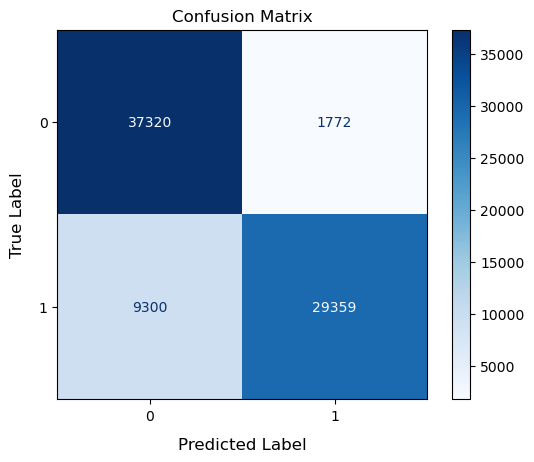

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import torch

model.eval()
with torch.no_grad():
    y_pred_probs = model(torch.tensor(X_test_lstm, dtype=torch.float32))
    y_pred_probs = y_pred_probs.cpu().numpy().flatten()  # continuous probabilities/scores

    # If model output logits, apply sigmoid:
    # y_pred_probs = torch.sigmoid(y_pred_probs).cpu().numpy().flatten()

    y_pred = (y_pred_probs > 0.5).astype(int)  # binary predictions for confusion matrix etc.

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(5, 3))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix', fontsize=12, fontweight='normal')
plt.xlabel('Predicted Label', fontsize=12, labelpad=10)
plt.ylabel('True Label', fontsize=12, labelpad=10)
plt.show()

In [ ]:
from sklearn.metrics import classification_report

# Generate the classification report
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

         0.0       0.80      0.95      0.87     39092
         1.0       0.94      0.76      0.84     38659

    accuracy                           0.86     77751
   macro avg       0.87      0.86      0.86     77751
weighted avg       0.87      0.86      0.86     77751



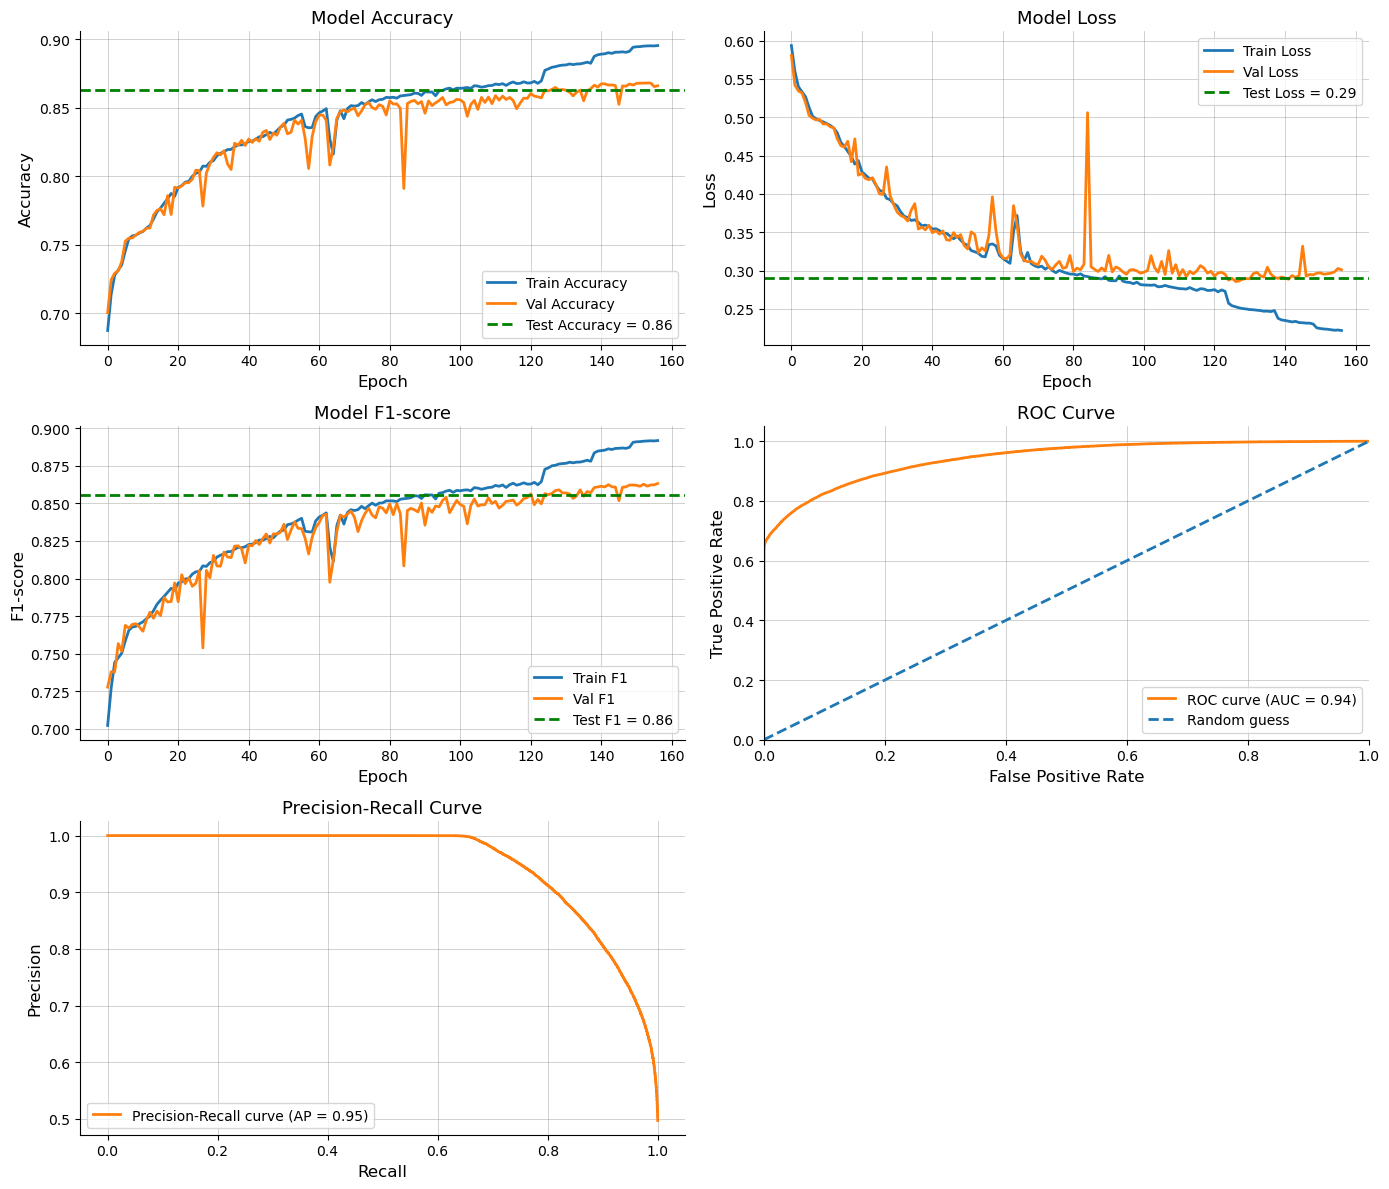

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score, f1_score

# Ensure y_test is numpy
y_test_np = np.array(y_test)

# ROC & AUC
fpr, tpr, _ = roc_curve(y_test_np, y_pred_probs)
roc_auc = auc(fpr, tpr)

# Precision-Recall
precision, recall, thresholds = precision_recall_curve(y_test_np, y_pred_probs)
ap = average_precision_score(y_test_np, y_pred_probs)

# Plot setup (3 rows × 2 columns)
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
fig.set_facecolor('white')

for ax in axes.flat:
    ax.grid(color='gray', linestyle='-', linewidth=0.5, alpha=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Accuracy curve
axes[0, 0].plot(train_accs, linewidth=2, color='#1f77b4', label='Train Accuracy')
axes[0, 0].plot(val_accs, linewidth=2, color='#ff7f0e', label='Val Accuracy')
axes[0, 0].axhline(y=test_accuracy, color='green', linestyle='--', linewidth=2,
                   label=f'Test Accuracy = {test_accuracy:.2f}')
axes[0, 0].set_title('Model Accuracy', fontsize=13)
axes[0, 0].set_ylabel('Accuracy', fontsize=12)
axes[0, 0].set_xlabel('Epoch', fontsize=12)
axes[0, 0].legend(loc='lower right', fontsize=10)

# Loss curve
axes[0, 1].plot(train_losses, linewidth=2, color='#1f77b4', label='Train Loss')
axes[0, 1].plot(val_losses, linewidth=2, color='#ff7f0e', label='Val Loss')
axes[0, 1].axhline(y=test_loss, color='green', linestyle='--', linewidth=2,
                   label=f'Test Loss = {test_loss:.2f}')
axes[0, 1].set_title('Model Loss', fontsize=13)
axes[0, 1].set_ylabel('Loss', fontsize=12)
axes[0, 1].set_xlabel('Epoch', fontsize=12)
axes[0, 1].legend(loc='upper right', fontsize=10)

# F1-score curve
axes[1, 0].plot(train_f1s, linewidth=2, color='#1f77b4', label='Train F1')
axes[1, 0].plot(val_f1s, linewidth=2, color='#ff7f0e', label='Val F1')
axes[1, 0].axhline(y=test_f1, color='green', linestyle='--', linewidth=2,
                   label=f'Test F1 = {test_f1:.2f}')
axes[1, 0].set_title('Model F1-score', fontsize=13)
axes[1, 0].set_ylabel('F1-score', fontsize=12)
axes[1, 0].set_xlabel('Epoch', fontsize=12)
axes[1, 0].legend(loc='lower right', fontsize=10)

# ROC Curve
axes[1, 1].plot(fpr, tpr, color='#ff7f0e', linewidth=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
axes[1, 1].plot([0, 1], [0, 1], color='#1f77b4', linewidth=2, linestyle='--', label='Random guess')
axes[1, 1].set_xlim([0.0, 1.0])
axes[1, 1].set_ylim([0.0, 1.05])
axes[1, 1].set_xlabel('False Positive Rate', fontsize=12)
axes[1, 1].set_ylabel('True Positive Rate', fontsize=12)
axes[1, 1].set_title('ROC Curve', fontsize=13)
axes[1, 1].legend(loc='lower right', fontsize=10)

# Precision-Recall Curve
axes[2, 0].plot(recall, precision, color='#ff7f0e', linewidth=2,
                label=f'Precision-Recall curve (AP = {ap:.2f})')
axes[2, 0].set_xlabel('Recall', fontsize=12)
axes[2, 0].set_ylabel('Precision', fontsize=12)
axes[2, 0].set_title('Precision-Recall Curve', fontsize=13)
axes[2, 0].legend(loc="lower left", fontsize=10)

# Remove empty subplot (bottom-right corner)
fig.delaxes(axes[2, 1])

plt.tight_layout()
plt.savefig("training_results_with_f1.png", dpi=300, bbox_inches="tight")
plt.show()

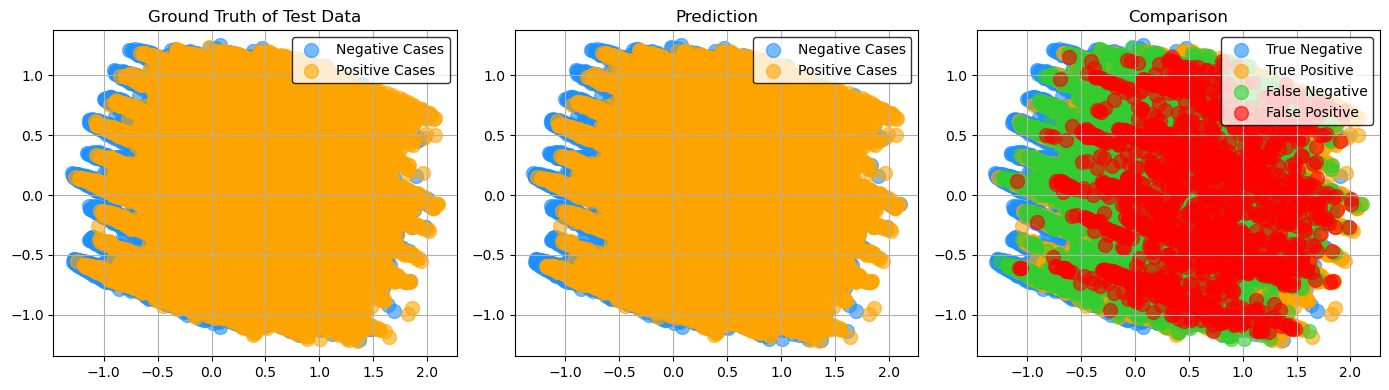

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def pca_plot(test_x_scaled, test_y, test_y_pred, size=100, markersize=1):
    pca = PCA(n_components=2)
    x_pca = pca.fit_transform(test_x_scaled)

    true_np = np.hstack((x_pca, test_y.reshape(len(test_y), 1)))
    pred_np = np.hstack((x_pca, test_y_pred.reshape(len(test_y_pred), 1)))

    column_true = ['pc_0', 'pc_1', 'true']
    column_pred = ['pc_0', 'pc_1', 'pred']

    true_df = pd.DataFrame(data=true_np, columns=column_true)
    pred_df = pd.DataFrame(data=pred_np, columns=column_pred)

    true_df_0 = true_df[true_df['true'] == 0]
    true_df_1 = true_df[true_df['true'] == 1]
    true_x_0 = true_df_0.iloc[:, :-1].to_numpy()
    true_x_1 = true_df_1.iloc[:, :-1].to_numpy()

    pred_df_0 = pred_df[pred_df['pred'] == 0]
    pred_df_1 = pred_df[pred_df['pred'] == 1]
    pred_x_0 = pred_df_0.iloc[:, :-1].to_numpy()
    pred_x_1 = pred_df_1.iloc[:, :-1].to_numpy()

    join_df = true_df.join(pred_df['pred'], rsuffix='_pred')

    correct_df = join_df[join_df['true'] == join_df['pred']]
    wrong_df = join_df[join_df['true'] != join_df['pred']]

    correct_df_0 = correct_df[correct_df['true'] == 0]
    correct_df_1 = correct_df[correct_df['true'] == 1]
    correct_x_0 = correct_df_0.iloc[:, :-2].to_numpy()
    correct_x_1 = correct_df_1.iloc[:, :-2].to_numpy()

    fn_df = wrong_df[wrong_df['pred'] == 0]
    fp_df = wrong_df[wrong_df['pred'] == 1]
    fn_x = fn_df.iloc[:, :-2].to_numpy()
    fp_x = fp_df.iloc[:, :-2].to_numpy()

    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 4))

    # Plot Ground Truth
    ax1.scatter(true_x_0[:, 0], true_x_0[:, 1], c='dodgerblue', s=size, alpha=0.6, label='Negative Cases')
    ax1.scatter(true_x_1[:, 0], true_x_1[:, 1], c='orange', s=size, alpha=0.6, label='Positive Cases')
    ax1.legend(markerscale=markersize, loc='best', frameon=True, facecolor='white', edgecolor='black')
    ax1.set_title('Ground Truth of Test Data', fontsize=12)
    # ax1.set_xlabel('Principal Component 1', fontsize=12)
    # ax1.set_ylabel('Principal Component 2', fontsize=12)
    ax1.grid(True)

    # Plot Predictions
    ax2.scatter(pred_x_0[:, 0], pred_x_0[:, 1], c='dodgerblue', s=size, alpha=0.6, label='Negative Cases')
    ax2.scatter(pred_x_1[:, 0], pred_x_1[:, 1], c='orange', s=size, alpha=0.6, label='Positive Cases')
    ax2.legend(markerscale=markersize, loc='best', frameon=True, facecolor='white', edgecolor='black')
    ax2.set_title('Prediction', fontsize=12)
    # ax2.set_xlabel('Principal Component 1', fontsize=12)
    # ax2.set_ylabel('Principal Component 2', fontsize=12)
    ax2.grid(True)

    # Plot Comparison
    ax3.scatter(correct_x_0[:, 0], correct_x_0[:, 1], c='dodgerblue', s=size, alpha=0.6, label='True Negative')
    ax3.scatter(correct_x_1[:, 0], correct_x_1[:, 1], c='orange', s=size, alpha=0.6, label='True Positive')
    ax3.scatter(fn_x[:, 0], fn_x[:, 1], c='limegreen', s=size, alpha=0.6, label='False Negative')
    ax3.scatter(fp_x[:, 0], fp_x[:, 1], c='red', s=size, alpha=0.6, label='False Positive')
    ax3.legend(markerscale=markersize, loc='best', frameon=True, facecolor='white', edgecolor='black')
    ax3.set_title('Comparison', fontsize=12)
    # ax3.set_xlabel('Principal Component 1', fontsize=12)
    # ax3.set_ylabel('Principal Component 2', fontsize=12)
    ax3.grid(True)

    plt.tight_layout()
    plt.show()

# Example usage:
pca_plot(X_test, y_test, y_pred, size=100, markersize=1)
